<img src="Logo_UNSAM.png" width="180">

### Análisis y Procesamiento de Señales

# Trabajo Práctico N°3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.

### Paulina Benito

#### Introducción 
El desparramo espectral es el efecto por el cual una componente que idealmente estaría concentrada en una frecuencia termina apareciendo ocupando un cierto ancho alrededor de ella al analizar un tramo finito de la señal. En el siguiente informe se analizará dicho efecto a partir de señales senoidales con pequeñas desintonías respecto de $\Delta f$, observando cómo estas variaciones modifican su densidad espectral de potencia. Además, se verificará la potencia de las señales mediante la identidad de Parseval y se estudiará qué ocurre al aplicar la técnica de zero-padding.

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

def funcion_sen( vmax , dc, k , ph, N,  fs) : 
    nn= np.arange(0,N,)
    xx = dc + vmax * np.sin(k*(2*np.pi*fs/N)*nn/fs + ph)

    return (nn,xx)

#### 1. Sea $k_0$
##### 1.1 $N/4$

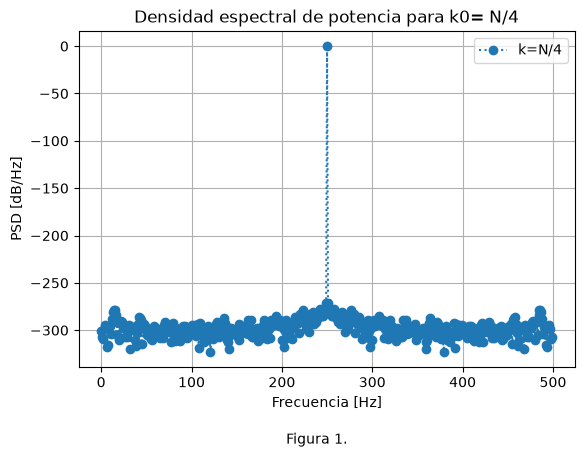

In [3]:
vmax= np.sqrt(2)
N=1000
k=N/4
ph=0
dc=0
fs=1000
nn,xx= funcion_sen(vmax, dc, k, ph, N, fs)
frec=np.arange(N//2) * fs/N
nXX = 1/N*np.fft.fft(xx)

plt.plot(frec, 10*np.log10(2*(np.abs(nXX[:N//2])**2)), ':o', label='k=N/4')
plt.ylabel("PSD [dB/Hz]")
plt.xlabel("Frecuencia [Hz]")
plt.title("Densidad espectral de potencia para k0= N/4")
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 1. ",
            ha="center")
plt.legend()
plt.grid()

Para $k_0=N/4$, la frecuencia de la senoide resulta $f_0=250 Hz$. Como la resolución frecuencial es $\Delta f=1 Hz$, dicha frecuencia coincide exactamente con uno de los bins de la DFT. Por este motivo, la potencia de la señal se concentra en un único punto del espectro y no se observa desparramo espectral. El pico alcanza $0 dB$ debido a que la senoide fue definida con potencia unitaria. Los valores extremadamente pequeños observados en el resto del espectro corresponden principalmente a errores numéricos del cálculo.

In [4]:
pot_frec1=np.sum(np.abs(nXX)**2)
print(pot_frec1)

1.0000000000000002


##### 1.2 $N/4 + 0.25$

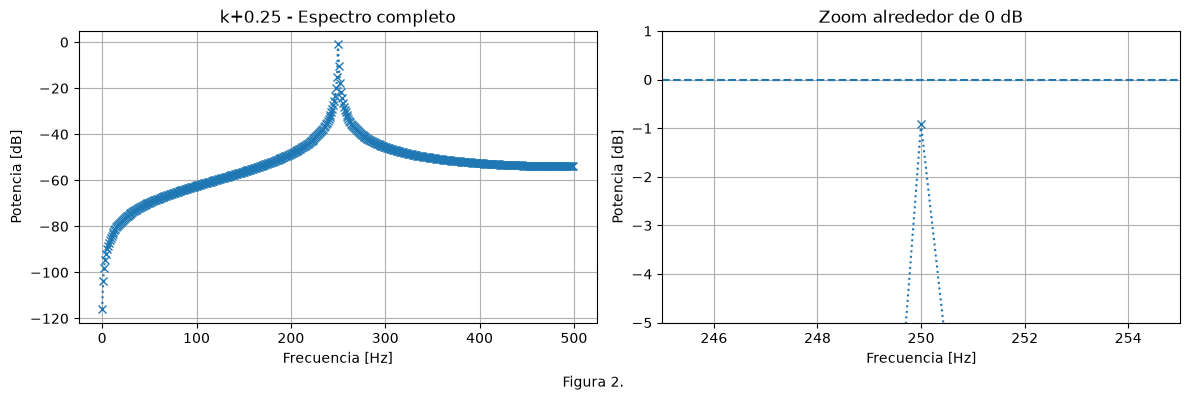

In [5]:
vmax= np.sqrt(2)
N=1000
k=N/4
ph=0
dc=0
fs=1000

nn,xx2= funcion_sen(vmax, dc, k+0.25, ph, N, fs)
eXX = 1/N*np.fft.fft(xx2)
PSD=  10*np.log10(2*(np.abs(eXX[:N//2])**2))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Grafico completo
ax[0].plot(frec, PSD, ':x')
ax[0].set_title('k+0.25 - Espectro completo')
ax[0].set_xlabel('Frecuencia [Hz]')
ax[0].set_ylabel('Potencia [dB]')
ax[0].grid()

# Zoom alrededor del pico
ax[1].plot(frec, PSD, ':x')
ax[1].set_xlim(245, 255)
ax[1].set_ylim(-5, 1)
ax[1].axhline(0, linestyle='--')
ax[1].set_title('Zoom alrededor de 0 dB')
ax[1].set_xlabel('Frecuencia [Hz]')
ax[1].set_ylabel('Potencia [dB]')
ax[1].grid()

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 2. ",
            ha="center")

plt.show()

En este caso, como $k= k_0+0.25$,al aplicar la DFT , la frecuencia de la señal no coincide con un bin. Como cosecuencia, la potencia de la senoidal no va a estar concentrada en un bin solo, sino que se distribuye entre varios bins debido al desparramo espectrl. Es por ello que el pico máximo del espectro no llega a los $0 db$. 

In [6]:
pot_frec2=np.sum(np.abs(eXX)**2)
print(pot_frec2)

0.9990000000000012


##### 1.3 $N/4 + 0.50$

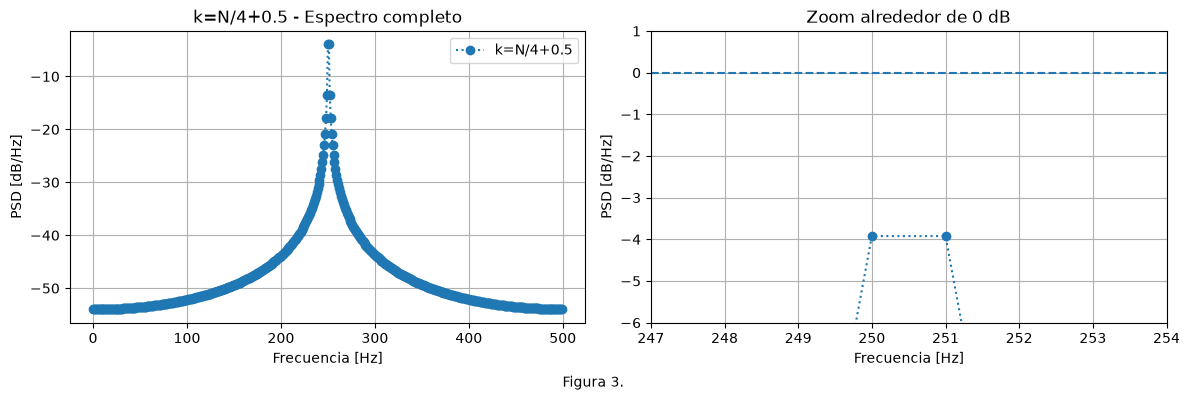

In [7]:
vmax= np.sqrt(2)
N=1000
k=N/4
ph=0
dc=0
fs=1000
nn,xx3= funcion_sen(vmax, dc, k+0.50, ph, N, fs)
frec=np.arange(N//2) * fs/N
nnXX = 1/N*np.fft.fft(xx3)

PSD = 10*np.log10(2*(np.abs(nnXX[:N//2])**2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Espectro completo
ax[0].plot(frec, PSD, ':o', label='k=N/4+0.5')
ax[0].set_title('k=N/4+0.5 - Espectro completo')
ax[0].set_xlabel('Frecuencia [Hz]')
ax[0].set_ylabel('PSD [dB/Hz]')
ax[0].grid()
ax[0].legend()

# Zoom
ax[1].plot(frec, PSD, ':o')
ax[1].set_xlim(247, 254)
ax[1].set_ylim(-6, 1)
ax[1].axhline(0, linestyle='--')
ax[1].set_title('Zoom alrededor de 0 dB')
ax[1].set_xlabel('Frecuencia [Hz]')
ax[1].set_ylabel('PSD [dB/Hz]')
ax[1].grid()

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 3. ",
            ha="center")

plt.show()

Para $k= k_0 +0.5$ pasa algo parecido. En este caso, la frecuencia de la señal queda entre dos bins por lo que la energía no se va a concentrar en un solo punto del espectro y va a haber desparramo espectral. Como se muestra en el zoom, aparece como una "meseta" entre dos puntos. Esto se debe a que como $\Delta{f}= 1 Hz$, la $f_0= 250.5$ y , como la DFT no encuentra un bin en ese punto, la potencia de la señal quedará a la misma distancia entre las frecuencias de $250 Hz$ y $251 Hz$, haciendo que ambos bins tengan el mismo valor. Se dice que es la posición menos favorable, por ende se encontrará más por debajo del pico de los $0 db$.

In [8]:
pot_frec3=np.sum(np.abs(nnXX)**2)
print(pot_frec3)

1.0000000000000007


Para cada caso se calculó la potencia del dominio de frecuencia y se puede observar como, si bien el espectro cambia, la potencia no. Esto se debe a que al variar $k_0$ no cambio el nivel de potencia sino como se distribuye entre bins de la DFT.

##### 2. Zero-padding

A continuación se aplicó zero padding a las señales analizadas, agregando 9N ceros a las N muestras originales. De esta manera, la cantidad de puntos utilizados para calcular la DFT aumenta de N a 10N, reduciendo la separación entre bins de frecuencia. El zero padding no agrega nueva información a la señal ni mejora la resolución espectral real, sino que permite obtener una representación más densa del espectro y localizar con mayor precisión sus máximo.

##### 2.1 Para $k_0=N/4$

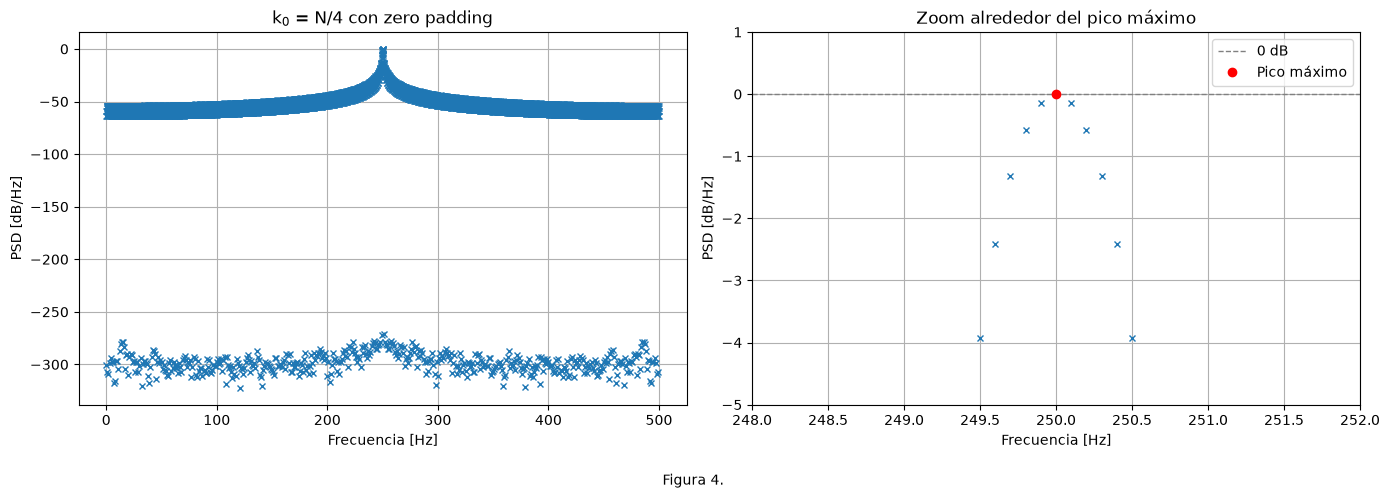

Frecuencia del máximo = 250.0 Hz
Valor máximo de PSD = 9.64327466553287e-16 dB


In [9]:
ceros = np.zeros(9*N)
xx1_zp = np.concatenate((xx, ceros))
frec2 = np.arange((10*N)//2) * fs / (10*N)
pXX = (1/N) * np.fft.fft(xx1_zp)
PSD = 10*np.log10(2*(np.abs(pXX[:(10*N)//2])**2))

imax = np.argmax(PSD)
fmax = frec2[imax]
psdmax = PSD[imax]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(frec2, PSD, 'x', markersize=4)
ax1.set_title(r'k$_0$ = N/4 con zero padding')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('PSD [dB/Hz]')
ax1.grid(True)


ax2.plot(frec2, PSD, 'x', markersize=5)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1, label='0 dB')
ax2.plot(fmax, psdmax, 'ro', label='Pico máximo')

ax2.set_title('Zoom alrededor del pico máximo')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [dB/Hz]')
ax2.set_xlim(fmax - 2, fmax + 2)    
ax2.set_ylim(psdmax - 5, 1)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 4. ",
            ha="center")

plt.show()

print("Frecuencia del máximo =", fmax, "Hz")
print("Valor máximo de PSD =", psdmax, "dB")

En la Figura 4 se muestra la densidad espectral de potencia de la señal para $k_0=N/4$ luego de aplicar zero padding. Como la frecuencia de la senoidal coincide exactamente con un bin de la DFT, la energía permanece concentrada en torno a su frecuencia correspondiente y el pico máximo se observa claramente. El zero padding no modifica la potencia de la señal, pero permite una representación más densa del espectro, facilitando la visualización del máximo.

##### 2.2 Para $k_0= N/4 + 0.25$

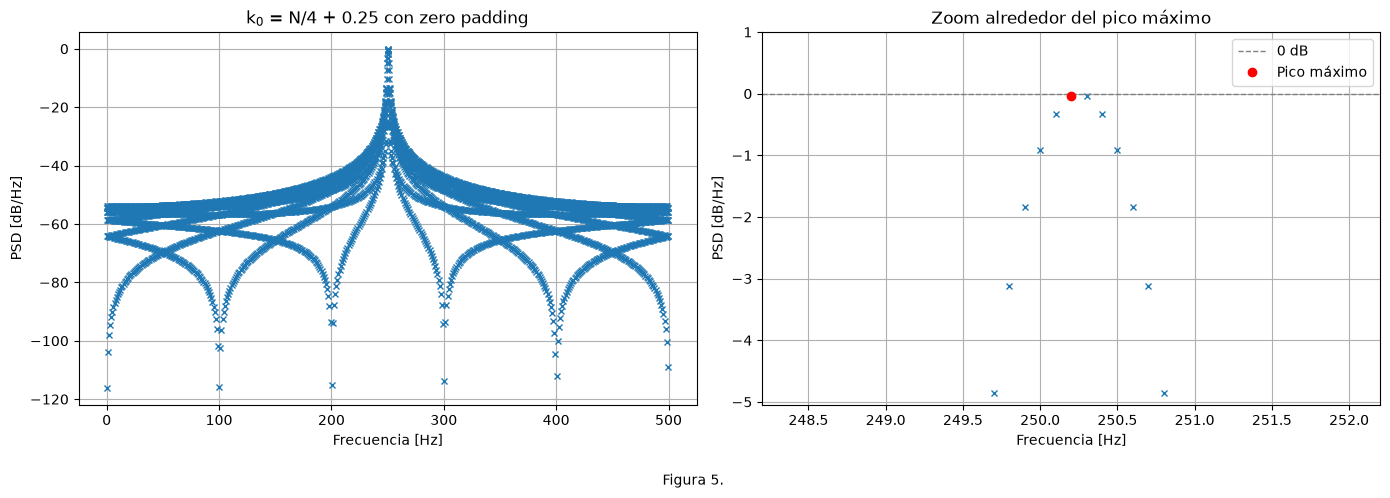

Frecuencia del máximo = 250.2 Hz
Valor máximo de PSD = -0.04436728345701438 dB


In [10]:
xx2_zp = np.concatenate((xx2, ceros))
X2_zp = (1/N)*(np.fft.fft(xx2_zp))
PSD = 10*np.log10(2*(np.abs(X2_zp[:(10*N)//2])**2))

imax = np.argmax(PSD)
fmax = frec2[imax]
psdmax = PSD[imax]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(frec2, PSD, 'x', markersize=4)
ax1.set_title(r'k$_0$ = N/4 + 0.25 con zero padding')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('PSD [dB/Hz]')
ax1.grid(True)


ax2.plot(frec2, PSD, 'x', markersize=5)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1, label='0 dB')
ax2.plot(fmax, psdmax, 'ro', label='Pico máximo')

ax2.set_title('Zoom alrededor del pico máximo')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [dB/Hz]')
ax2.set_xlim(fmax - 2, fmax + 2)    
ax2.set_ylim(psdmax - 5, 1)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 5. ",
            ha="center")

plt.show()

print("Frecuencia del máximo =", fmax, "Hz")
print("Valor máximo de PSD =", psdmax, "dB")

En la Figura 5 se muestra el espectro correspondiente al caso $k_0 = N/4 + 0.25$ luego de aplicar zero padding. Como la frecuencia de la señal no coincide exactamente con un bin de la DFT, sigue observándose desparramo espectral. Sin embargo, al aumentar la cantidad de puntos de la transformada mediante el agregado de ceros, se obtiene una grilla de frecuencias más densa, lo que permite ubicar con mayor precisión el máximo del espectro. En este caso, el valor máximo se encontró en $f_{\max}=250.2 Hz $, con una PSD de aproximadamente $-0.044 dB $, es decir, muy próxima a $0 dB$. Esto confirma que el zero padding no elimina el desparramo ni modifica la potencia de la señal, sino que mejora la visualización del espectro y la estimación de la ubicación y valor del pico.

##### 2.3 Para $k_0= N/4 + 0.5$ 

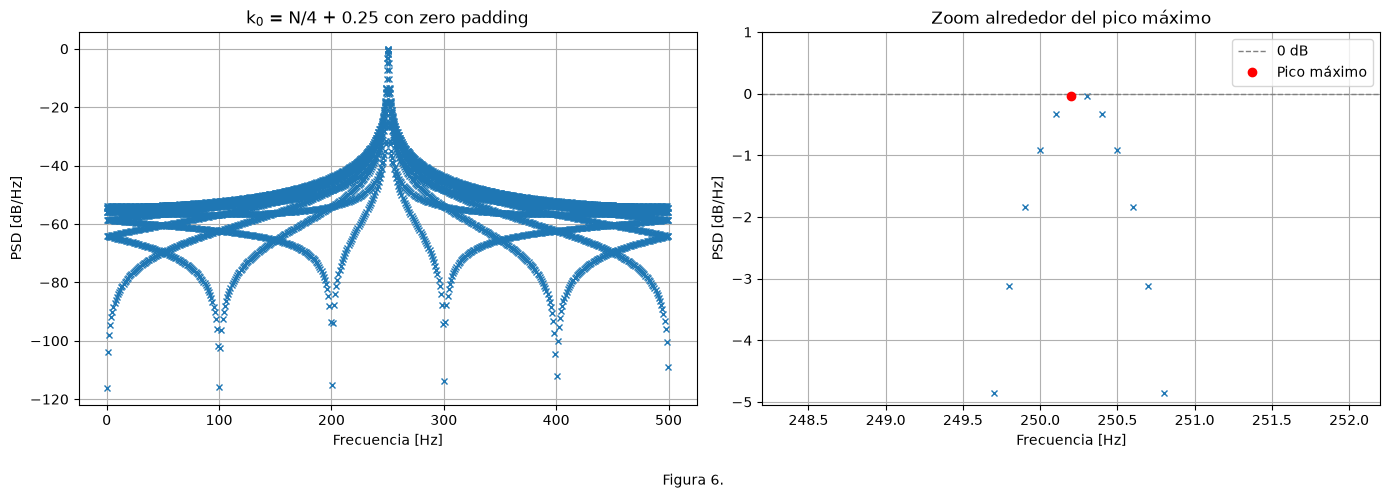

Frecuencia del máximo = 250.2 Hz
Valor máximo de PSD = -0.04436728345701438 dB


In [11]:
xx3_zp = np.concatenate((xx3, ceros))
X3_zp = (1/N)*(np.fft.fft(xx3_zp))
PSD = 10*np.log10(2*(np.abs(X2_zp[:(10*N)//2])**2))

imax = np.argmax(PSD)
fmax = frec2[imax]
psdmax = PSD[imax]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(frec2, PSD, 'x', markersize=4)
ax1.set_title(r'k$_0$ = N/4 + 0.25 con zero padding')
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('PSD [dB/Hz]')
ax1.grid(True)


ax2.plot(frec2, PSD, 'x', markersize=5)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1, label='0 dB')
ax2.plot(fmax, psdmax, 'ro', label='Pico máximo')

ax2.set_title('Zoom alrededor del pico máximo')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD [dB/Hz]')
ax2.set_xlim(fmax - 2, fmax + 2)    
ax2.set_ylim(psdmax - 5, 1)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 6. ",
            ha="center")

plt.show()
print("Frecuencia del máximo =", fmax, "Hz")
print("Valor máximo de PSD =", psdmax, "dB")

En la Figura 6 se presenta el caso $k_0=N/4+0.5$ con zero padding. Al quedar la frecuencia de la señal exactamente entre dos bins de la DFT, la energía no se concentra en un único punto sino que se distribuye entre bins vecinos, dando lugar al máximo desparramo espectral entre los casos analizados. El zero padding permite visualizar con mayor detalle la forma del lóbulo principal y estimar con mayor precisión la ubicación del máximo, pero no modifica la potencia de la señal ni elimina el desparramo. Por eso, el valor máximo de la PSD permanece por debajo de 0 $dB$.

#### Conclusion 

A lo largo de este trabajo práctico se analizó el efecto del desparramo espectral producido al calcular la DFT de una señal senoidal cuando su frecuencia no coincide exactamente con los bins de la transformada. Para $k_0=N/4$, la frecuencia coincide con un bin y la potencia se concentra en un único punto del espectro. En cambio, para $k_0=N/4+0.25$ y $k_0=N/4+0.5$, la frecuencia queda desalineada respecto de la grilla de la DFT y la potencia se distribuye entre varios bins, siendo el caso de $+0.5$ el de mayor desajuste. Mediante Parseval se verificó que, aunque la forma del espectro cambia, la potencia total de la señal se mantiene aproximadamente en $1 W$, por lo que el desparramo no implica una pérdida de potencia sino una redistribución de la misma. Finalmente, al aplicar zero padding se obtuvo una mayor cantidad de puntos en frecuencia, lo que permitió visualizar con mayor detalle la forma del espectro y localizar mejor sus máximos. Sin embargo, se comprobó que el zero padding no agrega nueva información ni elimina el desparramo espectral, sino que permite una representación más densa del mismo espectro.